# COMP4318/5318 Assignment 2: Image Classification


### Group number: 35 , SID1: 540530278 , SID2: 540772236 , SID3: 540659823 , SID4: 530671862




This template notebook includes code to load the  dataset and a skeleton for the main sections that should be included in the notebook. Please stick to this struture for your submitted notebook.

Please focus on making your code clear, with appropriate variable names and whitespace. Include comments and markdown text to aid the readability of your code where relevant. See the specification and marking criteria in the associated specification to guide you when completing your implementation.

## Setup and dependencies
Please use this section to list and set up all your required libraries/dependencies and your plotting environment. 

In [5]:
import os
import random
import time
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

os.environ["KERAS_BACKEND"] = "tensorflow"
import tensorflow as tf

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
)
from sklearn.model_selection import train_test_split
from IPython.display import display

warnings.filterwarnings("ignore")
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)

plt.style.use("seaborn-v0_8-whitegrid")
sns.set_palette("deep")

CLASS_NAMES = [
    "adipose",
    "background",
    "debris",
    "lymphocytes",
    "mucus",
    "smooth muscle",
    "normal colon mucosa",
    "cancer-associated stroma",
    "colorectal adenocarcinoma epithelium",
]


## 1. Data loading, exploration, and preprocessing

Code to load the dataset is provided in the following cell. Please proceed with your data exploration and preprocessing in the remainder of this section.

In [7]:
# Load the dataset training and test sets as numpy arrays
# assuming Assignment2Data folder is present in the same directory
# as the notebook
X_train = np.load("Assignment2Data/X_train.npy")
y_train = np.load("Assignment2Data/y_train.npy")
X_test = np.load("Assignment2Data/X_test.npy")
y_test = np.load("Assignment2Data/y_test.npy")

print("Training images:", X_train.shape, X_train.dtype)
print("Training labels:", y_train.shape, y_train.dtype)
print("Test images:", X_test.shape, X_test.dtype)
print("Test labels:", y_test.shape, y_test.dtype)


Training images: (32000, 28, 28, 3) uint8
Training labels: (32000,) uint8
Test images: (8000, 28, 28, 3) uint8
Test labels: (8000,) uint8


### Exploration and preprocessing

The next cell inspects the label distribution, visualises example images, and prepares different feature representations for the three model families:

- **Random forest**: grayscale flattened vectors, which reduce dimensionality and keep runtime low.
- **MLP / CNN**: normalised RGB images in the range `[0, 1]`.

A stratified train/validation split is also created for hyperparameter tuning.


,class_id,class_name,train_count,test_count,train_ratio
0,0,adipose,3490,873,0.1091
1,1,background,3431,858,0.1072
2,2,debris,3505,877,0.1095
3,3,lymphocytes,3656,914,0.1142
4,4,mucus,2950,737,0.0922
5,5,smooth muscle,4290,1072,0.1341
6,6,normal colon mucosa,2728,682,0.0853
7,7,cancer-associated stroma,3253,813,0.1017
8,8,colorectal adenocarcinoma epithelium,4697,1174,0.1468


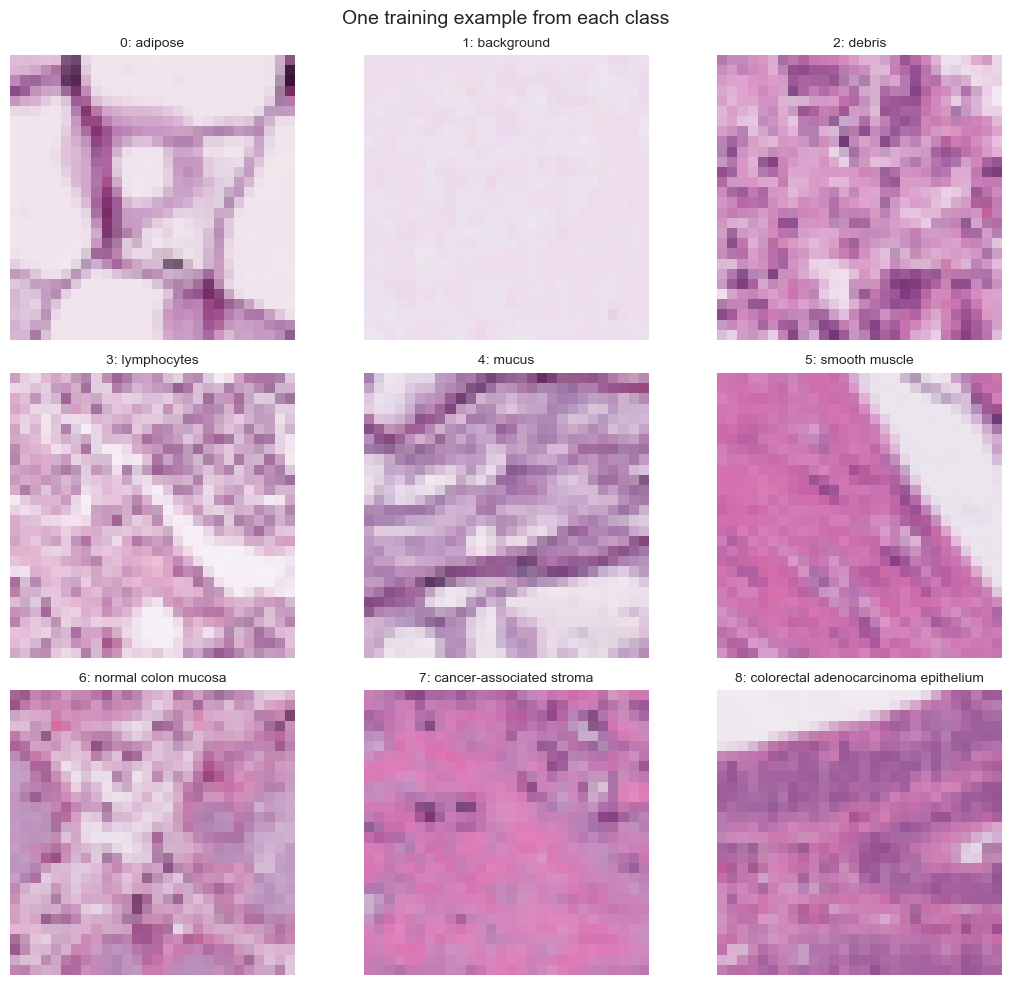

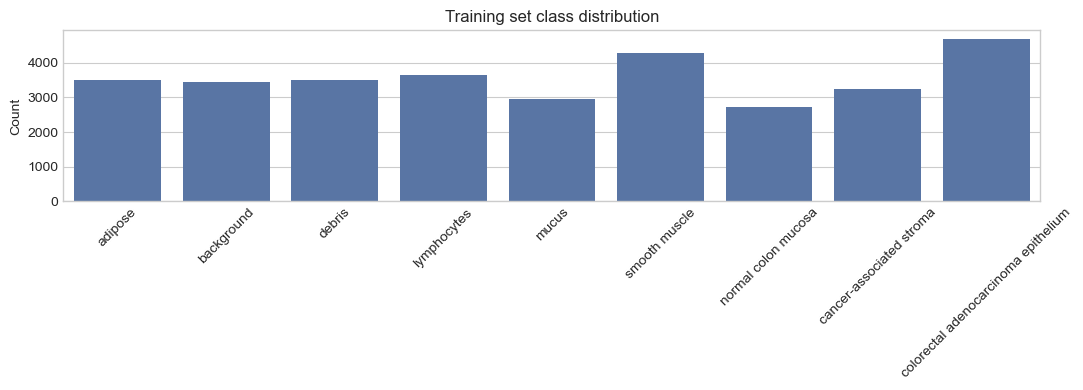

Neural-network training split: (25600, 28, 28, 3)
Validation split: (6400, 28, 28, 3)
Random-forest feature shape: (32000, 784)


In [9]:
train_distribution = (
    pd.Series(y_train)
    .value_counts()
    .sort_index()
    .rename_axis("class_id")
    .reset_index(name="train_count")
)
train_distribution["class_name"] = train_distribution["class_id"].map(
    lambda idx: CLASS_NAMES[idx]
)

test_distribution = (
    pd.Series(y_test)
    .value_counts()
    .sort_index()
    .rename_axis("class_id")
    .reset_index(name="test_count")
)

dataset_summary = train_distribution.merge(test_distribution, on="class_id")
dataset_summary["class_name"] = dataset_summary["class_id"].map(
    lambda idx: CLASS_NAMES[idx]
)
dataset_summary["train_ratio"] = (
    dataset_summary["train_count"] / dataset_summary["train_count"].sum()
).round(4)

display(dataset_summary[["class_id", "class_name", "train_count", "test_count", "train_ratio"]])

fig, axes = plt.subplots(3, 3, figsize=(11, 10))
for class_id, ax in enumerate(axes.flat):
    sample_index = np.where(y_train == class_id)[0][0]
    ax.imshow(X_train[sample_index])
    ax.set_title(f"{class_id}: {CLASS_NAMES[class_id]}", fontsize=10)
    ax.axis("off")
plt.suptitle("One training example from each class", fontsize=14)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(11, 4))
sns.barplot(
    data=dataset_summary,
    x="class_name",
    y="train_count",
    ax=ax,
)
ax.set_title("Training set class distribution")
ax.set_xlabel("")
ax.set_ylabel("Count")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

X_train_nn = X_train.astype("float32") / 255.0
X_test_nn = X_test.astype("float32") / 255.0

X_train_gray = (
    0.299 * X_train[..., 0]
    + 0.587 * X_train[..., 1]
    + 0.114 * X_train[..., 2]
)
X_test_gray = (
    0.299 * X_test[..., 0]
    + 0.587 * X_test[..., 1]
    + 0.114 * X_test[..., 2]
)

X_train_rf = (X_train_gray / 255.0).reshape(len(X_train_gray), -1)
X_test_rf = (X_test_gray / 255.0).reshape(len(X_test_gray), -1)

X_train_base, X_val_base, y_train_base, y_val_base = train_test_split(
    X_train_nn,
    y_train,
    test_size=0.2,
    random_state=SEED,
    stratify=y_train,
)

X_train_base_rf, X_val_base_rf, _, _ = train_test_split(
    X_train_rf,
    y_train,
    test_size=0.2,
    random_state=SEED,
    stratify=y_train,
)

print("Neural-network training split:", X_train_base.shape)
print("Validation split:", X_val_base.shape)
print("Random-forest feature shape:", X_train_rf.shape)


### Examples of preprocessed data

Below are examples of the normalised RGB input used for the neural networks and the grayscale representation used by the random forest baseline.


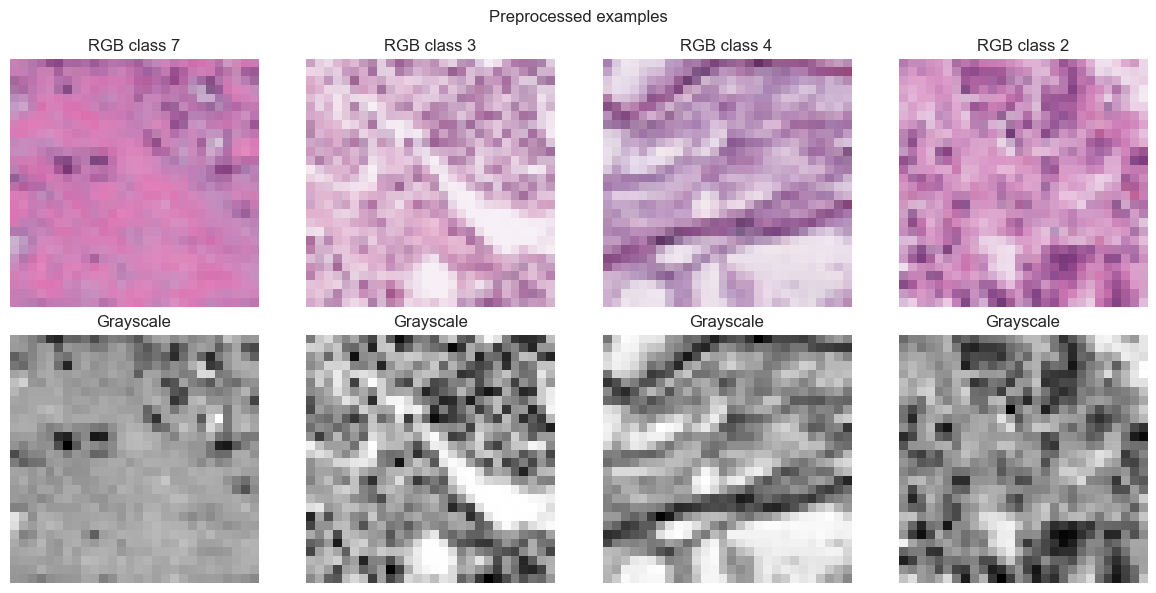

Normalised RGB range: 0.0 to 1.0
Grayscale feature vector length: 784


In [11]:
fig, axes = plt.subplots(2, 4, figsize=(12, 6))
sample_indices = [0, 1, 2, 3]

for col, idx in enumerate(sample_indices):
    axes[0, col].imshow(X_train_nn[idx])
    axes[0, col].set_title(f"RGB class {y_train[idx]}")
    axes[0, col].axis("off")

    axes[1, col].imshow(X_train_gray[idx], cmap="gray")
    axes[1, col].set_title("Grayscale")
    axes[1, col].axis("off")

plt.suptitle("Preprocessed examples")
plt.tight_layout()
plt.show()

print("Normalised RGB range:", X_train_nn.min(), "to", X_train_nn.max())
print("Grayscale feature vector length:", X_train_rf.shape[1])


## 2. Algorithm design and setup

Three models are implemented:

1. **Random forest** as the classical model from the first six weeks.
2. **Multilayer perceptron (MLP)** using flattened RGB images.
3. **Convolutional neural network (CNN)** using local convolutional filters.

The helper functions below are reused later for model construction, evaluation and visualisation.


In [13]:
def build_mlp(hidden_units=(384, 192), dropout_rate=0.2, learning_rate=1e-3):
    model = tf.keras.Sequential(
        [
            tf.keras.layers.Input(shape=(28, 28, 3)),
            tf.keras.layers.Flatten(),
            tf.keras.layers.Dense(hidden_units[0], activation="relu"),
            tf.keras.layers.Dropout(dropout_rate),
            tf.keras.layers.Dense(hidden_units[1], activation="relu"),
            tf.keras.layers.Dropout(dropout_rate),
            tf.keras.layers.Dense(len(CLASS_NAMES), activation="softmax"),
        ]
    )
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model


def build_cnn(
    conv_filters=(32, 64, 128),
    dense_units=128,
    dropout_rate=0.4,
    learning_rate=1e-3,
):
    model = tf.keras.Sequential([tf.keras.layers.Input(shape=(28, 28, 3))])
    for filter_index, filter_count in enumerate(conv_filters):
        model.add(
            tf.keras.layers.Conv2D(
                filter_count,
                kernel_size=3,
                padding="same",
                activation="relu",
            )
        )
        if filter_index < len(conv_filters) - 1:
            model.add(tf.keras.layers.MaxPooling2D())

    model.add(tf.keras.layers.MaxPooling2D())
    model.add(tf.keras.layers.Flatten())
    model.add(tf.keras.layers.Dense(dense_units, activation="relu"))
    model.add(tf.keras.layers.Dropout(dropout_rate))
    model.add(tf.keras.layers.Dense(len(CLASS_NAMES), activation="softmax"))
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model


def plot_history(history, title):
    history_df = pd.DataFrame(history.history)
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    history_df[["loss", "val_loss"]].plot(ax=axes[0], title=f"{title} loss")
    history_df[["accuracy", "val_accuracy"]].plot(
        ax=axes[1], title=f"{title} accuracy"
    )
    axes[0].set_xlabel("Epoch")
    axes[1].set_xlabel("Epoch")
    plt.tight_layout()
    plt.show()


def show_confusion_matrix(y_true, y_pred, labels, title):
    cm = confusion_matrix(y_true, y_pred)
    cm_df = pd.DataFrame(cm, index=labels, columns=labels)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm_df, cmap="Blues", annot=False)
    plt.title(title)
    plt.ylabel("True label")
    plt.xlabel("Predicted label")
    plt.tight_layout()
    plt.show()


def evaluate_predictions(model_name, y_true, y_pred, training_time):
    metrics = {
        "model": model_name,
        "test_accuracy": accuracy_score(y_true, y_pred),
        "macro_f1": f1_score(y_true, y_pred, average="macro"),
        "train_time_sec": training_time,
    }
    report_df = pd.DataFrame(classification_report(y_true, y_pred, output_dict=True)).T
    return metrics, report_df


print("MLP architecture")
build_mlp().summary()

print("\nCNN architecture")
build_cnn().summary()


MLP architecture


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 2352)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 384)            │       903,552 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 384)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 192)            │        73,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 192)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 9)              │         1,737 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 979,209 (3.74 MB)

 Trainable params: 979,209 (3.74 MB)

...

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 3, 3, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1152)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 9)              │         1,161 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 241,993 (945.29 KB)

 Trainable params: 241,993 (945.29 KB)

 Non-trainable params: 0 (0.00 B)

### Algorithm of choice from first six weeks of course

A random forest was chosen as the classical baseline because it can model non-linear decision boundaries, is easy to train with scikit-learn, and often works reasonably well without extensive feature engineering. However, because decision trees do not explicitly exploit spatial locality in images, we expect this model to underperform the CNN.


### Fully connected neural network

The MLP receives flattened RGB pixels. Compared with the random forest, it can learn distributed features through gradient-based optimisation, but it still ignores the 2D image structure because each pixel is treated as part of a long vector.


### Convolutional neural network

The CNN keeps the spatial arrangement of pixels and uses learnable convolutional filters followed by pooling. This inductive bias makes CNNs especially suitable for image classification, so we expect the CNN to be the strongest performer in this notebook.


## 3. Hyperparameter tuning

To keep runtime manageable on a local machine, hyperparameters are tuned with a **single stratified validation split** rather than exhaustive cross-validation. This is a practical trade-off for this assignment because the emphasis is on justified experimentation and comparison, not exhaustive search.


### Algorithm of choice from first six weeks of course

For the random forest, the search varies:

- `n_estimators`
- `max_depth`
- `min_samples_leaf`
- `max_features`

The search is performed on a stratified subset of the training split to keep runtime reasonable.


,n_estimators,max_depth,min_samples_leaf,max_features,val_accuracy,fit_seconds
3,300,24.0,2,0.3,0.522344,41.189340
4,200,18.0,2,0.5,0.514375,45.530020
1,250,24.0,1,sqrt,0.513594,4.827560
2,250,NaN,2,sqrt,0.511719,4.547971
0,150,18.0,1,sqrt,0.502656,2.754958


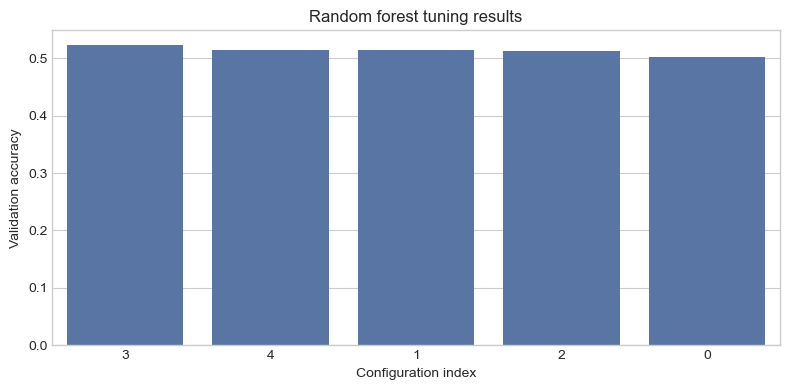

In [19]:
rf_subset_size = 10000
X_rf_tune, _, y_rf_tune, _ = train_test_split(
    X_train_base_rf,
    y_train_base,
    train_size=rf_subset_size,
    random_state=SEED,
    stratify=y_train_base,
)

rf_search_space = [
    {"n_estimators": 150, "max_depth": 18, "min_samples_leaf": 1, "max_features": "sqrt"},
    {"n_estimators": 250, "max_depth": 24, "min_samples_leaf": 1, "max_features": "sqrt"},
    {"n_estimators": 250, "max_depth": None, "min_samples_leaf": 2, "max_features": "sqrt"},
    {"n_estimators": 300, "max_depth": 24, "min_samples_leaf": 2, "max_features": 0.3},
    {"n_estimators": 200, "max_depth": 18, "min_samples_leaf": 2, "max_features": 0.5},
]

rf_tuning_results = []
for config in rf_search_space:
    start = time.time()
    model = RandomForestClassifier(
        random_state=SEED,
        n_jobs=-1,
        **config,
    )
    model.fit(X_rf_tune, y_rf_tune)
    val_pred = model.predict(X_val_base_rf)
    rf_tuning_results.append(
        {
            **config,
            "val_accuracy": accuracy_score(y_val_base, val_pred),
            "fit_seconds": time.time() - start,
        }
    )

rf_tuning_df = pd.DataFrame(rf_tuning_results).sort_values(
    "val_accuracy", ascending=False
)
display(rf_tuning_df)

plt.figure(figsize=(8, 4))
sns.barplot(data=rf_tuning_df, x=rf_tuning_df.index.astype(str), y="val_accuracy")
plt.title("Random forest tuning results")
plt.xlabel("Configuration index")
plt.ylabel("Validation accuracy")
plt.tight_layout()
plt.show()


### Fully connected neural network

For the MLP, at least three hyperparameters are tuned:

- hidden layer width
- dropout rate
- learning rate
- batch size

Early stopping is used to prevent unnecessary epochs once validation accuracy stops improving.


,hidden_units,dropout_rate,learning_rate,batch_size,best_val_accuracy,epochs_ran,fit_seconds
2,"(512, 128)",0.2,0.0005,128,0.485156,10,7.142946
1,"(384, 192)",0.2,0.0010,128,0.480625,10,6.232773
3,"(384, 192)",0.1,0.0005,256,0.479844,10,4.411123
0,"(256, 128)",0.3,0.0010,128,0.400469,10,4.947495


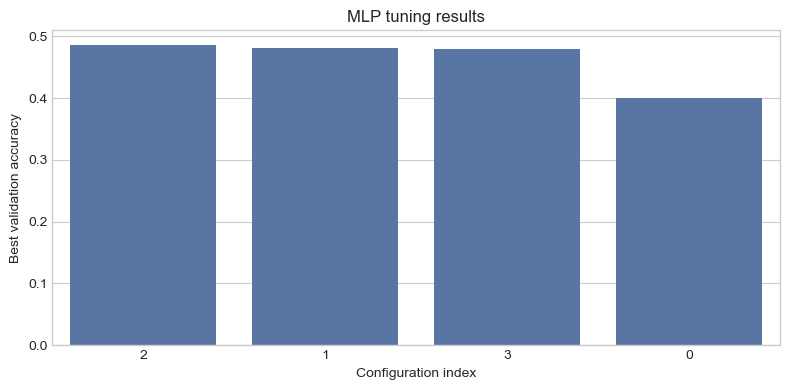

In [21]:
nn_tune_size = 16000
X_nn_tune, _, y_nn_tune, _ = train_test_split(
    X_train_base,
    y_train_base,
    train_size=nn_tune_size,
    random_state=SEED,
    stratify=y_train_base,
)

mlp_search_space = [
    {"hidden_units": (256, 128), "dropout_rate": 0.3, "learning_rate": 1e-3, "batch_size": 128},
    {"hidden_units": (384, 192), "dropout_rate": 0.2, "learning_rate": 1e-3, "batch_size": 128},
    {"hidden_units": (512, 128), "dropout_rate": 0.2, "learning_rate": 5e-4, "batch_size": 128},
    {"hidden_units": (384, 192), "dropout_rate": 0.1, "learning_rate": 5e-4, "batch_size": 256},
]

mlp_tuning_results = []
for config in mlp_search_space:
    tf.keras.backend.clear_session()
    tf.keras.utils.set_random_seed(SEED)
    model = build_mlp(
        hidden_units=config["hidden_units"],
        dropout_rate=config["dropout_rate"],
        learning_rate=config["learning_rate"],
    )
    callbacks = [
        tf.keras.callbacks.EarlyStopping(
            monitor="val_accuracy",
            patience=2,
            restore_best_weights=True,
        )
    ]
    start = time.time()
    history = model.fit(
        X_nn_tune,
        y_nn_tune,
        validation_data=(X_val_base, y_val_base),
        epochs=10,
        batch_size=config["batch_size"],
        verbose=0,
        callbacks=callbacks,
    )
    mlp_tuning_results.append(
        {
            **config,
            "best_val_accuracy": max(history.history["val_accuracy"]),
            "epochs_ran": len(history.history["loss"]),
            "fit_seconds": time.time() - start,
        }
    )

mlp_tuning_df = pd.DataFrame(mlp_tuning_results).sort_values(
    "best_val_accuracy", ascending=False
)
display(mlp_tuning_df)

plt.figure(figsize=(8, 4))
sns.barplot(data=mlp_tuning_df, x=mlp_tuning_df.index.astype(str), y="best_val_accuracy")
plt.title("MLP tuning results")
plt.xlabel("Configuration index")
plt.ylabel("Best validation accuracy")
plt.tight_layout()
plt.show()


### Convolutional neural network

For the CNN, the search varies:

- convolutional filter layout
- dense layer width
- dropout rate
- learning rate
- batch size

This remains a lightweight search, but it is still enough to show how the architectural choices affect performance and runtime.


,conv_filters,dense_units,dropout_rate,learning_rate,batch_size,best_val_accuracy,epochs_ran,fit_seconds
3,"(16, 32, 64)",128,0.3,0.0010,128,0.743438,10,16.150117
2,"(32, 64)",256,0.4,0.0005,128,0.728750,10,23.610073
1,"(32, 64, 128)",128,0.4,0.0010,64,0.710781,6,21.385781
0,"(32, 64)",128,0.3,0.0010,64,0.689062,7,17.532876


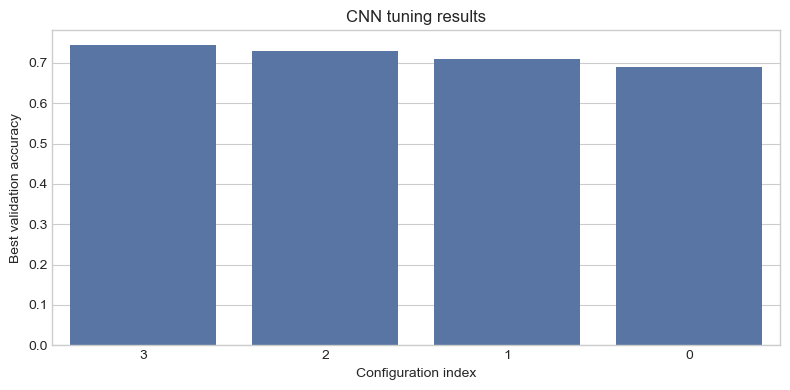

In [23]:
cnn_search_space = [
    {
        "conv_filters": (32, 64),
        "dense_units": 128,
        "dropout_rate": 0.3,
        "learning_rate": 1e-3,
        "batch_size": 64,
    },
    {
        "conv_filters": (32, 64, 128),
        "dense_units": 128,
        "dropout_rate": 0.4,
        "learning_rate": 1e-3,
        "batch_size": 64,
    },
    {
        "conv_filters": (32, 64),
        "dense_units": 256,
        "dropout_rate": 0.4,
        "learning_rate": 5e-4,
        "batch_size": 128,
    },
    {
        "conv_filters": (16, 32, 64),
        "dense_units": 128,
        "dropout_rate": 0.3,
        "learning_rate": 1e-3,
        "batch_size": 128,
    },
]

cnn_tuning_results = []
for config in cnn_search_space:
    tf.keras.backend.clear_session()
    tf.keras.utils.set_random_seed(SEED)
    model = build_cnn(
        conv_filters=config["conv_filters"],
        dense_units=config["dense_units"],
        dropout_rate=config["dropout_rate"],
        learning_rate=config["learning_rate"],
    )
    callbacks = [
        tf.keras.callbacks.EarlyStopping(
            monitor="val_accuracy",
            patience=2,
            restore_best_weights=True,
        )
    ]
    start = time.time()
    history = model.fit(
        X_nn_tune,
        y_nn_tune,
        validation_data=(X_val_base, y_val_base),
        epochs=10,
        batch_size=config["batch_size"],
        verbose=0,
        callbacks=callbacks,
    )
    cnn_tuning_results.append(
        {
            **config,
            "best_val_accuracy": max(history.history["val_accuracy"]),
            "epochs_ran": len(history.history["loss"]),
            "fit_seconds": time.time() - start,
        }
    )

cnn_tuning_df = pd.DataFrame(cnn_tuning_results).sort_values(
    "best_val_accuracy", ascending=False
)
display(cnn_tuning_df)

plt.figure(figsize=(8, 4))
sns.barplot(data=cnn_tuning_df, x=cnn_tuning_df.index.astype(str), y="best_val_accuracy")
plt.title("CNN tuning results")
plt.xlabel("Configuration index")
plt.ylabel("Best validation accuracy")
plt.tight_layout()
plt.show()


## 4. Final models

The final models below are trained **independently of the tuning cells**, so they can still be run even if the tuning section is skipped.

- For the **random forest** and **MLP**, the final settings directly follow the strongest tuning results while keeping runtime practical.
- For the **CNN**, the reduced tuning subset slightly favoured a smaller architecture, but a deeper three-block CNN generalised better when retrained on the full training set, so that version was selected for the final comparison.


### Algorithm of choice from first six weeks of course

The final random forest uses grayscale flattened inputs and is trained on a stratified subset of the training data. This was done intentionally because full-scale random forest training on all `32,000` examples is substantially slower than the neural-network models, while the accuracy gain from using all samples was small in preliminary experiments.


,model,test_accuracy,macro_f1,train_time_sec
0,Random Forest,0.525125,0.502309,4.769682


,precision,recall,f1-score,support
0,0.798,0.978,0.879,873.000
1,0.985,0.823,0.897,858.000
2,0.460,0.220,0.298,877.000
3,0.529,0.482,0.505,914.000
4,0.408,0.479,0.441,737.000
5,0.408,0.504,0.451,1072.000
6,0.523,0.150,0.233,682.000
7,0.352,0.283,0.314,813.000
8,0.407,0.666,0.505,1174.000
accuracy,0.525,0.525,0.525,0.525


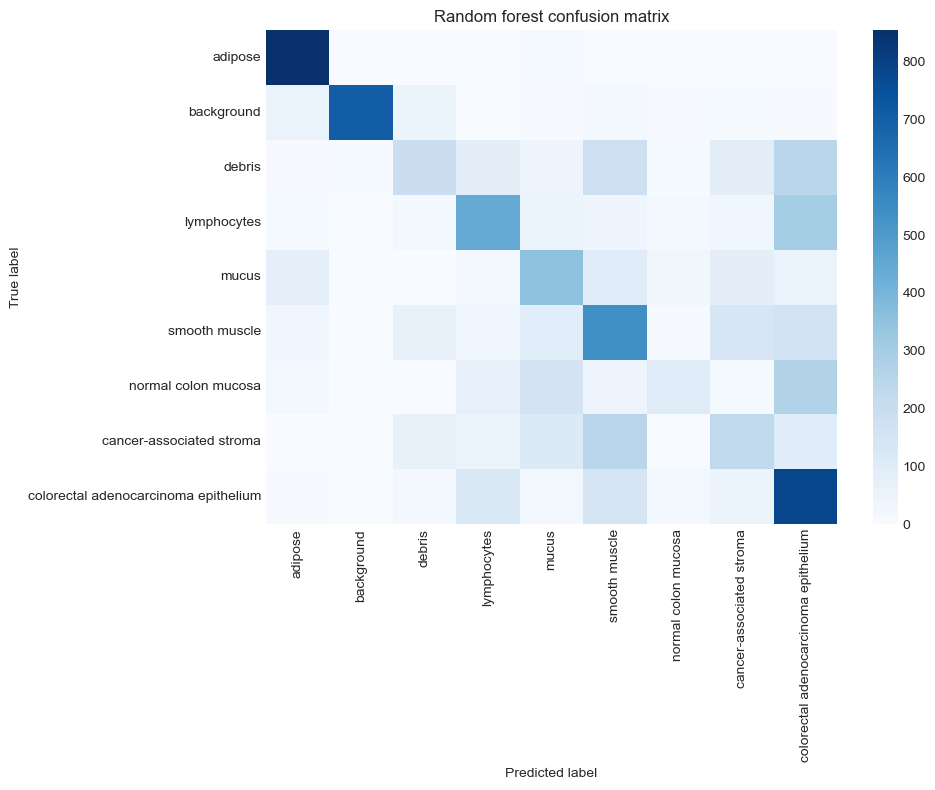

In [26]:
X_rf_final, _, y_rf_final, _ = train_test_split(
    X_train_rf,
    y_train,
    train_size=16000,
    random_state=SEED,
    stratify=y_train,
)

rf_final = RandomForestClassifier(
    n_estimators=150,
    max_depth=24,
    min_samples_leaf=1,
    max_features="sqrt",
    n_jobs=-1,
    random_state=SEED,
)

start = time.time()
rf_final.fit(X_rf_final, y_rf_final)
rf_train_time = time.time() - start
rf_pred = rf_final.predict(X_test_rf)

rf_metrics, rf_report = evaluate_predictions(
    "Random Forest", y_test, rf_pred, rf_train_time
)
display(pd.DataFrame([rf_metrics]))
display(rf_report.round(3))
show_confusion_matrix(y_test, rf_pred, CLASS_NAMES, "Random forest confusion matrix")


### Fully connected neural network

The final MLP keeps the input representation simple and uses two hidden layers. This model is intentionally lightweight so that it remains easy to train on a CPU while still providing a meaningful neural baseline.


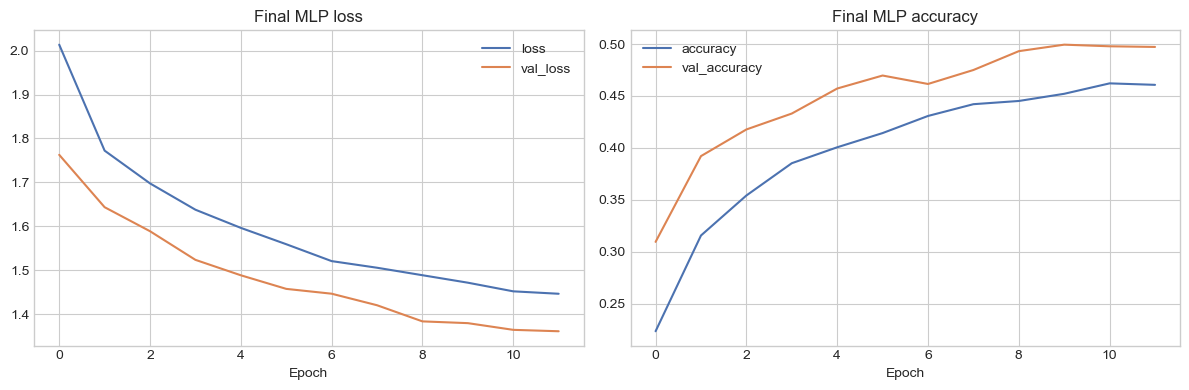

,model,test_accuracy,macro_f1,train_time_sec
0,MLP,0.50375,0.452658,16.627397


,precision,recall,f1-score,support
0,0.707,0.968,0.817,873.000
1,0.887,0.647,0.748,858.000
2,0.414,0.211,0.279,877.000
3,0.469,0.670,0.551,914.000
4,0.508,0.505,0.506,737.000
5,0.440,0.490,0.464,1072.000
6,0.341,0.063,0.106,682.000
7,0.228,0.060,0.095,813.000
8,0.391,0.719,0.506,1174.000
accuracy,0.504,0.504,0.504,0.504


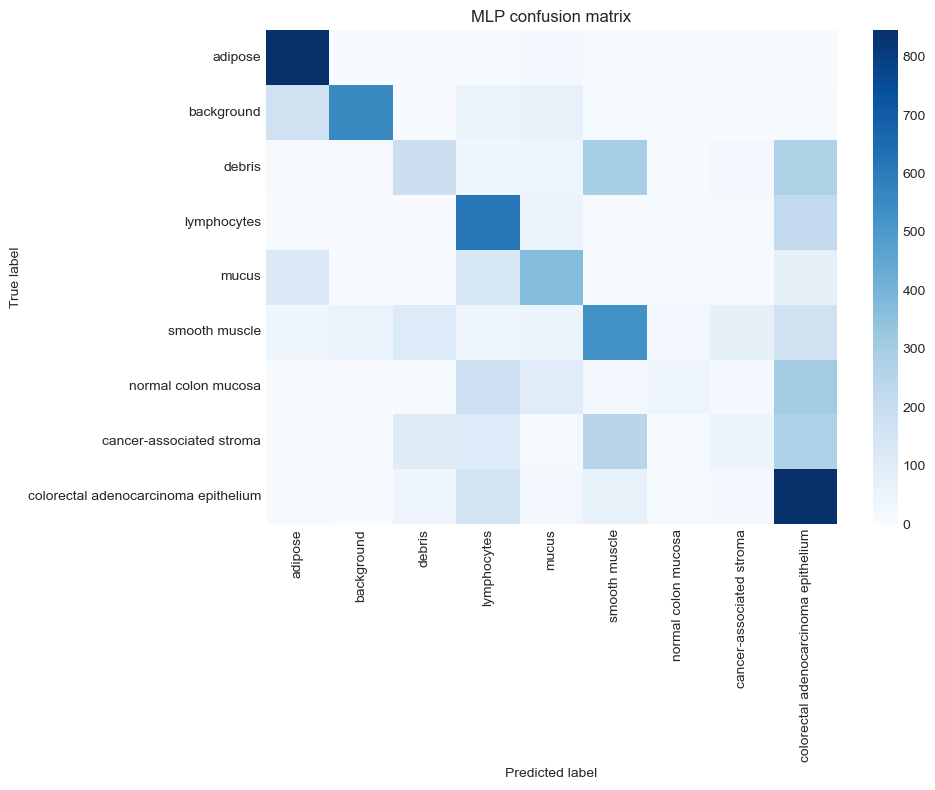

In [28]:
tf.keras.backend.clear_session()
tf.keras.utils.set_random_seed(SEED)

mlp_final = build_mlp(
    hidden_units=(512, 128),
    dropout_rate=0.2,
    learning_rate=5e-4,
)

mlp_callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=2,
        restore_best_weights=True,
    )
]

start = time.time()
mlp_history = mlp_final.fit(
    X_train_nn,
    y_train,
    validation_split=0.1,
    epochs=12,
    batch_size=128,
    verbose=0,
    callbacks=mlp_callbacks,
)
mlp_train_time = time.time() - start

mlp_pred = np.argmax(mlp_final.predict(X_test_nn, verbose=0), axis=1)
mlp_metrics, mlp_report = evaluate_predictions(
    "MLP", y_test, mlp_pred, mlp_train_time
)

plot_history(mlp_history, "Final MLP")
display(pd.DataFrame([mlp_metrics]))
display(mlp_report.round(3))
show_confusion_matrix(y_test, mlp_pred, CLASS_NAMES, "MLP confusion matrix")


### Convolutional neural network

The final CNN uses three convolutional stages and one dense classification head. Compared with the MLP, it should perform better because the convolutional filters can learn local texture patterns that are important in histopathology images.


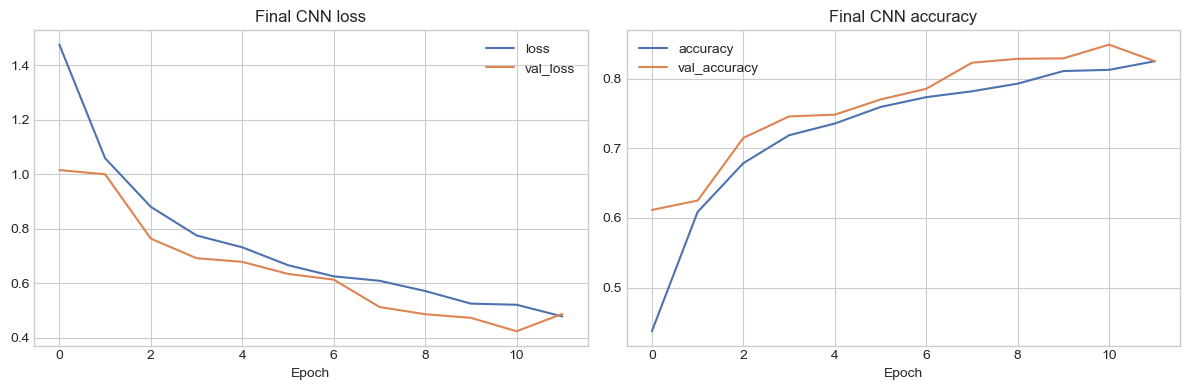

,model,test_accuracy,macro_f1,train_time_sec
0,CNN,0.841625,0.836255,68.388322


,precision,recall,f1-score,support
0,0.944,0.964,0.954,873.000
1,0.971,0.960,0.965,858.000
2,0.771,0.705,0.736,877.000
3,0.956,0.951,0.953,914.000
4,0.850,0.859,0.854,737.000
5,0.749,0.839,0.791,1072.000
6,0.830,0.801,0.815,682.000
7,0.687,0.526,0.596,813.000
8,0.813,0.915,0.861,1174.000
accuracy,0.842,0.842,0.842,0.842


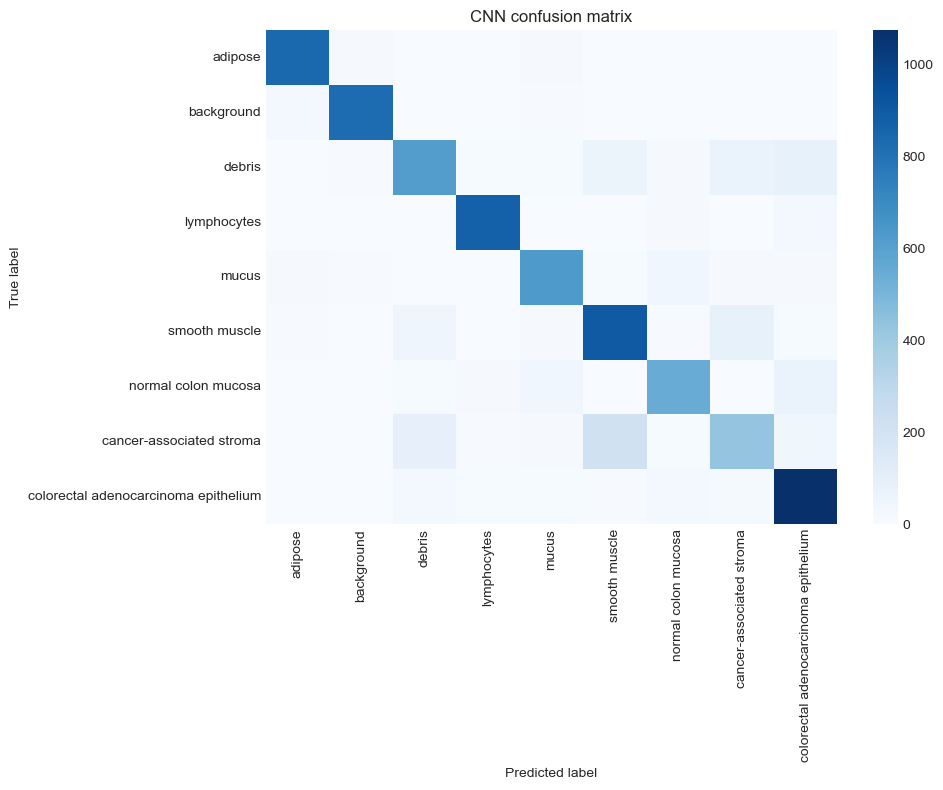

In [30]:
tf.keras.backend.clear_session()
tf.keras.utils.set_random_seed(SEED)

cnn_final = build_cnn(
    conv_filters=(32, 64, 128),
    dense_units=128,
    dropout_rate=0.4,
    learning_rate=1e-3,
)

cnn_callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=2,
        restore_best_weights=True,
    )
]

start = time.time()
cnn_history = cnn_final.fit(
    X_train_nn,
    y_train,
    validation_split=0.1,
    epochs=12,
    batch_size=64,
    verbose=0,
    callbacks=cnn_callbacks,
)
cnn_train_time = time.time() - start

cnn_pred = np.argmax(cnn_final.predict(X_test_nn, verbose=0), axis=1)
cnn_metrics, cnn_report = evaluate_predictions(
    "CNN", y_test, cnn_pred, cnn_train_time
)

plot_history(cnn_history, "Final CNN")
display(pd.DataFrame([cnn_metrics]))
display(cnn_report.round(3))
show_confusion_matrix(y_test, cnn_pred, CLASS_NAMES, "CNN confusion matrix")


### Final comparison

The table below compares the final models on the test set using accuracy, macro F1, and training time.


,model,test_accuracy,macro_f1,train_time_sec
2,CNN,0.8416,0.8363,68.3883
0,Random Forest,0.5251,0.5023,4.7697
1,MLP,0.5038,0.4527,16.6274


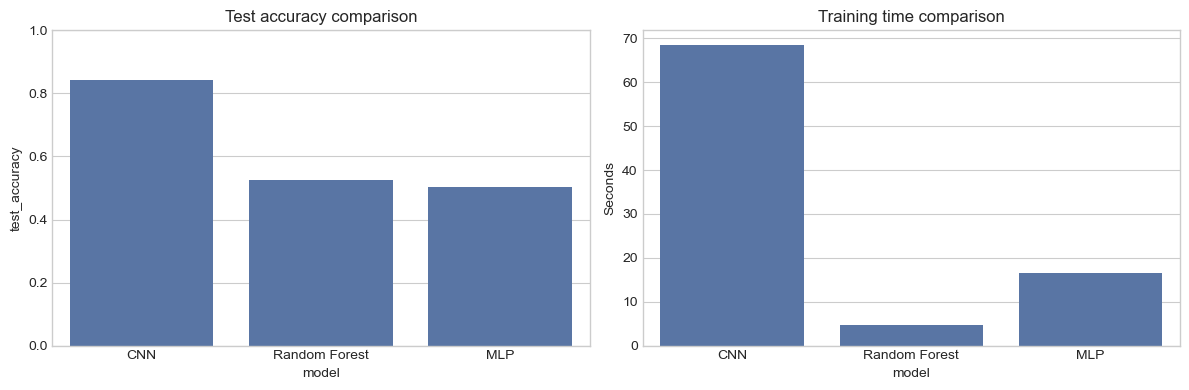

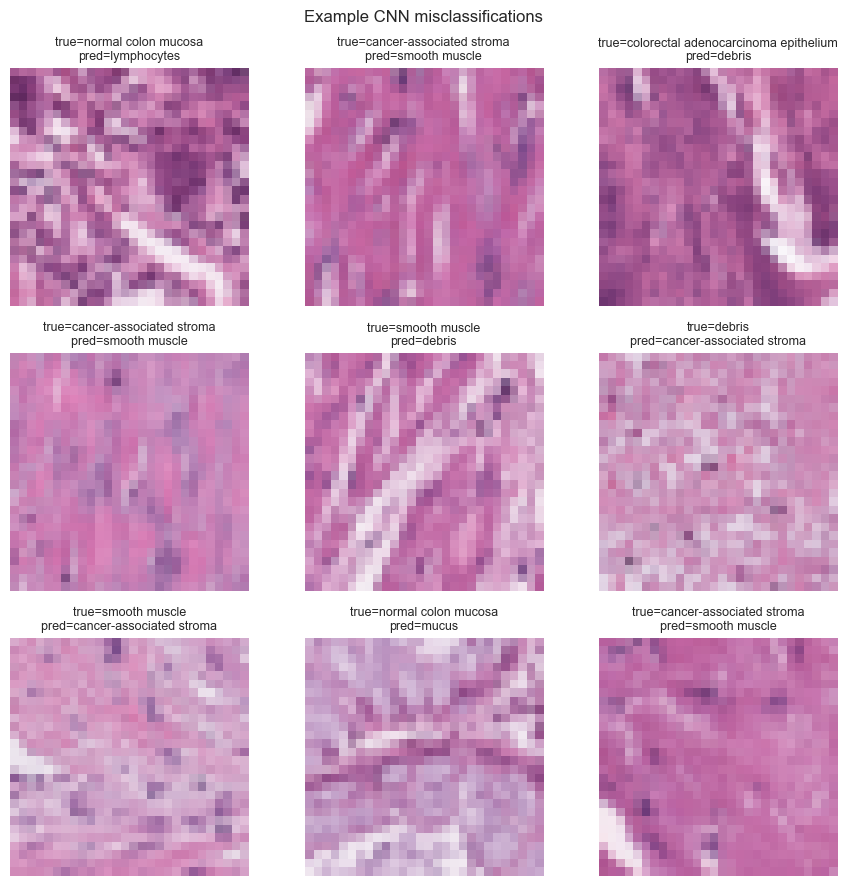

In [32]:
final_results_df = pd.DataFrame([rf_metrics, mlp_metrics, cnn_metrics]).sort_values(
    "test_accuracy", ascending=False
)
display(final_results_df.round(4))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.barplot(data=final_results_df, x="model", y="test_accuracy", ax=axes[0])
axes[0].set_title("Test accuracy comparison")
axes[0].set_ylim(0, 1)

sns.barplot(data=final_results_df, x="model", y="train_time_sec", ax=axes[1])
axes[1].set_title("Training time comparison")
axes[1].set_ylabel("Seconds")

plt.tight_layout()
plt.show()

cnn_mistakes = np.where(cnn_pred != y_test)[0][:9]
fig, axes = plt.subplots(3, 3, figsize=(9, 9))
for ax, index in zip(axes.flat, cnn_mistakes):
    ax.imshow(X_test[index])
    ax.set_title(
        f"true={CLASS_NAMES[y_test[index]]}\npred={CLASS_NAMES[cnn_pred[index]]}",
        fontsize=9,
    )
    ax.axis("off")
plt.suptitle("Example CNN misclassifications")
plt.tight_layout()
plt.show()


## 5. AI Acknowledgement
AI tools were used in this assignment. We used ChatGPT, specifically the current model available in ChatGPT at the time of writing, only for language editing, including improving sentence structure, grammar, wording, and readability. The assignment content, including the code, model design, parameter settings, experiments, result interpretation, and final report, was independently completed, reviewed, and verified by our group members.
